# Data Analysis

In [14]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
data_train = pd.read_csv('data/X_train.csv')
data_train.head()

,ROW_ID,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
0,0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4


In [16]:
# Check for missing values
missing_values = data_train.isnull().sum()
print("Missing Values per Column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found")
print(f"\nTotal missing values: {missing_values.sum()}")
print(f"Percentage of missing data: {(missing_values.sum() / (data_train.shape[0] * data_train.shape[1]) * 100):.2f}%")

Missing Values per Column:
RET_20                       58
RET_19                       50
RET_18                       42
RET_17                       34
RET_16                       26
RET_15                       18
RET_14                       13
RET_13                        9
RET_12                        6
RET_11                        4
RET_10                        2
SIGNED_VOLUME_20           8498
SIGNED_VOLUME_19           3002
SIGNED_VOLUME_18            859
SIGNED_VOLUME_17             58
SIGNED_VOLUME_16             50
SIGNED_VOLUME_15             42
SIGNED_VOLUME_14             34
SIGNED_VOLUME_13             26
SIGNED_VOLUME_12             18
SIGNED_VOLUME_11             13
SIGNED_VOLUME_10              9
SIGNED_VOLUME_9               6
SIGNED_VOLUME_8               4
SIGNED_VOLUME_7               2
SIGNED_VOLUME_1          387506
MEDIAN_DAILY_TURNOVER      3638
dtype: int64

Total missing values: 404027
Percentage of missing data: 1.70%


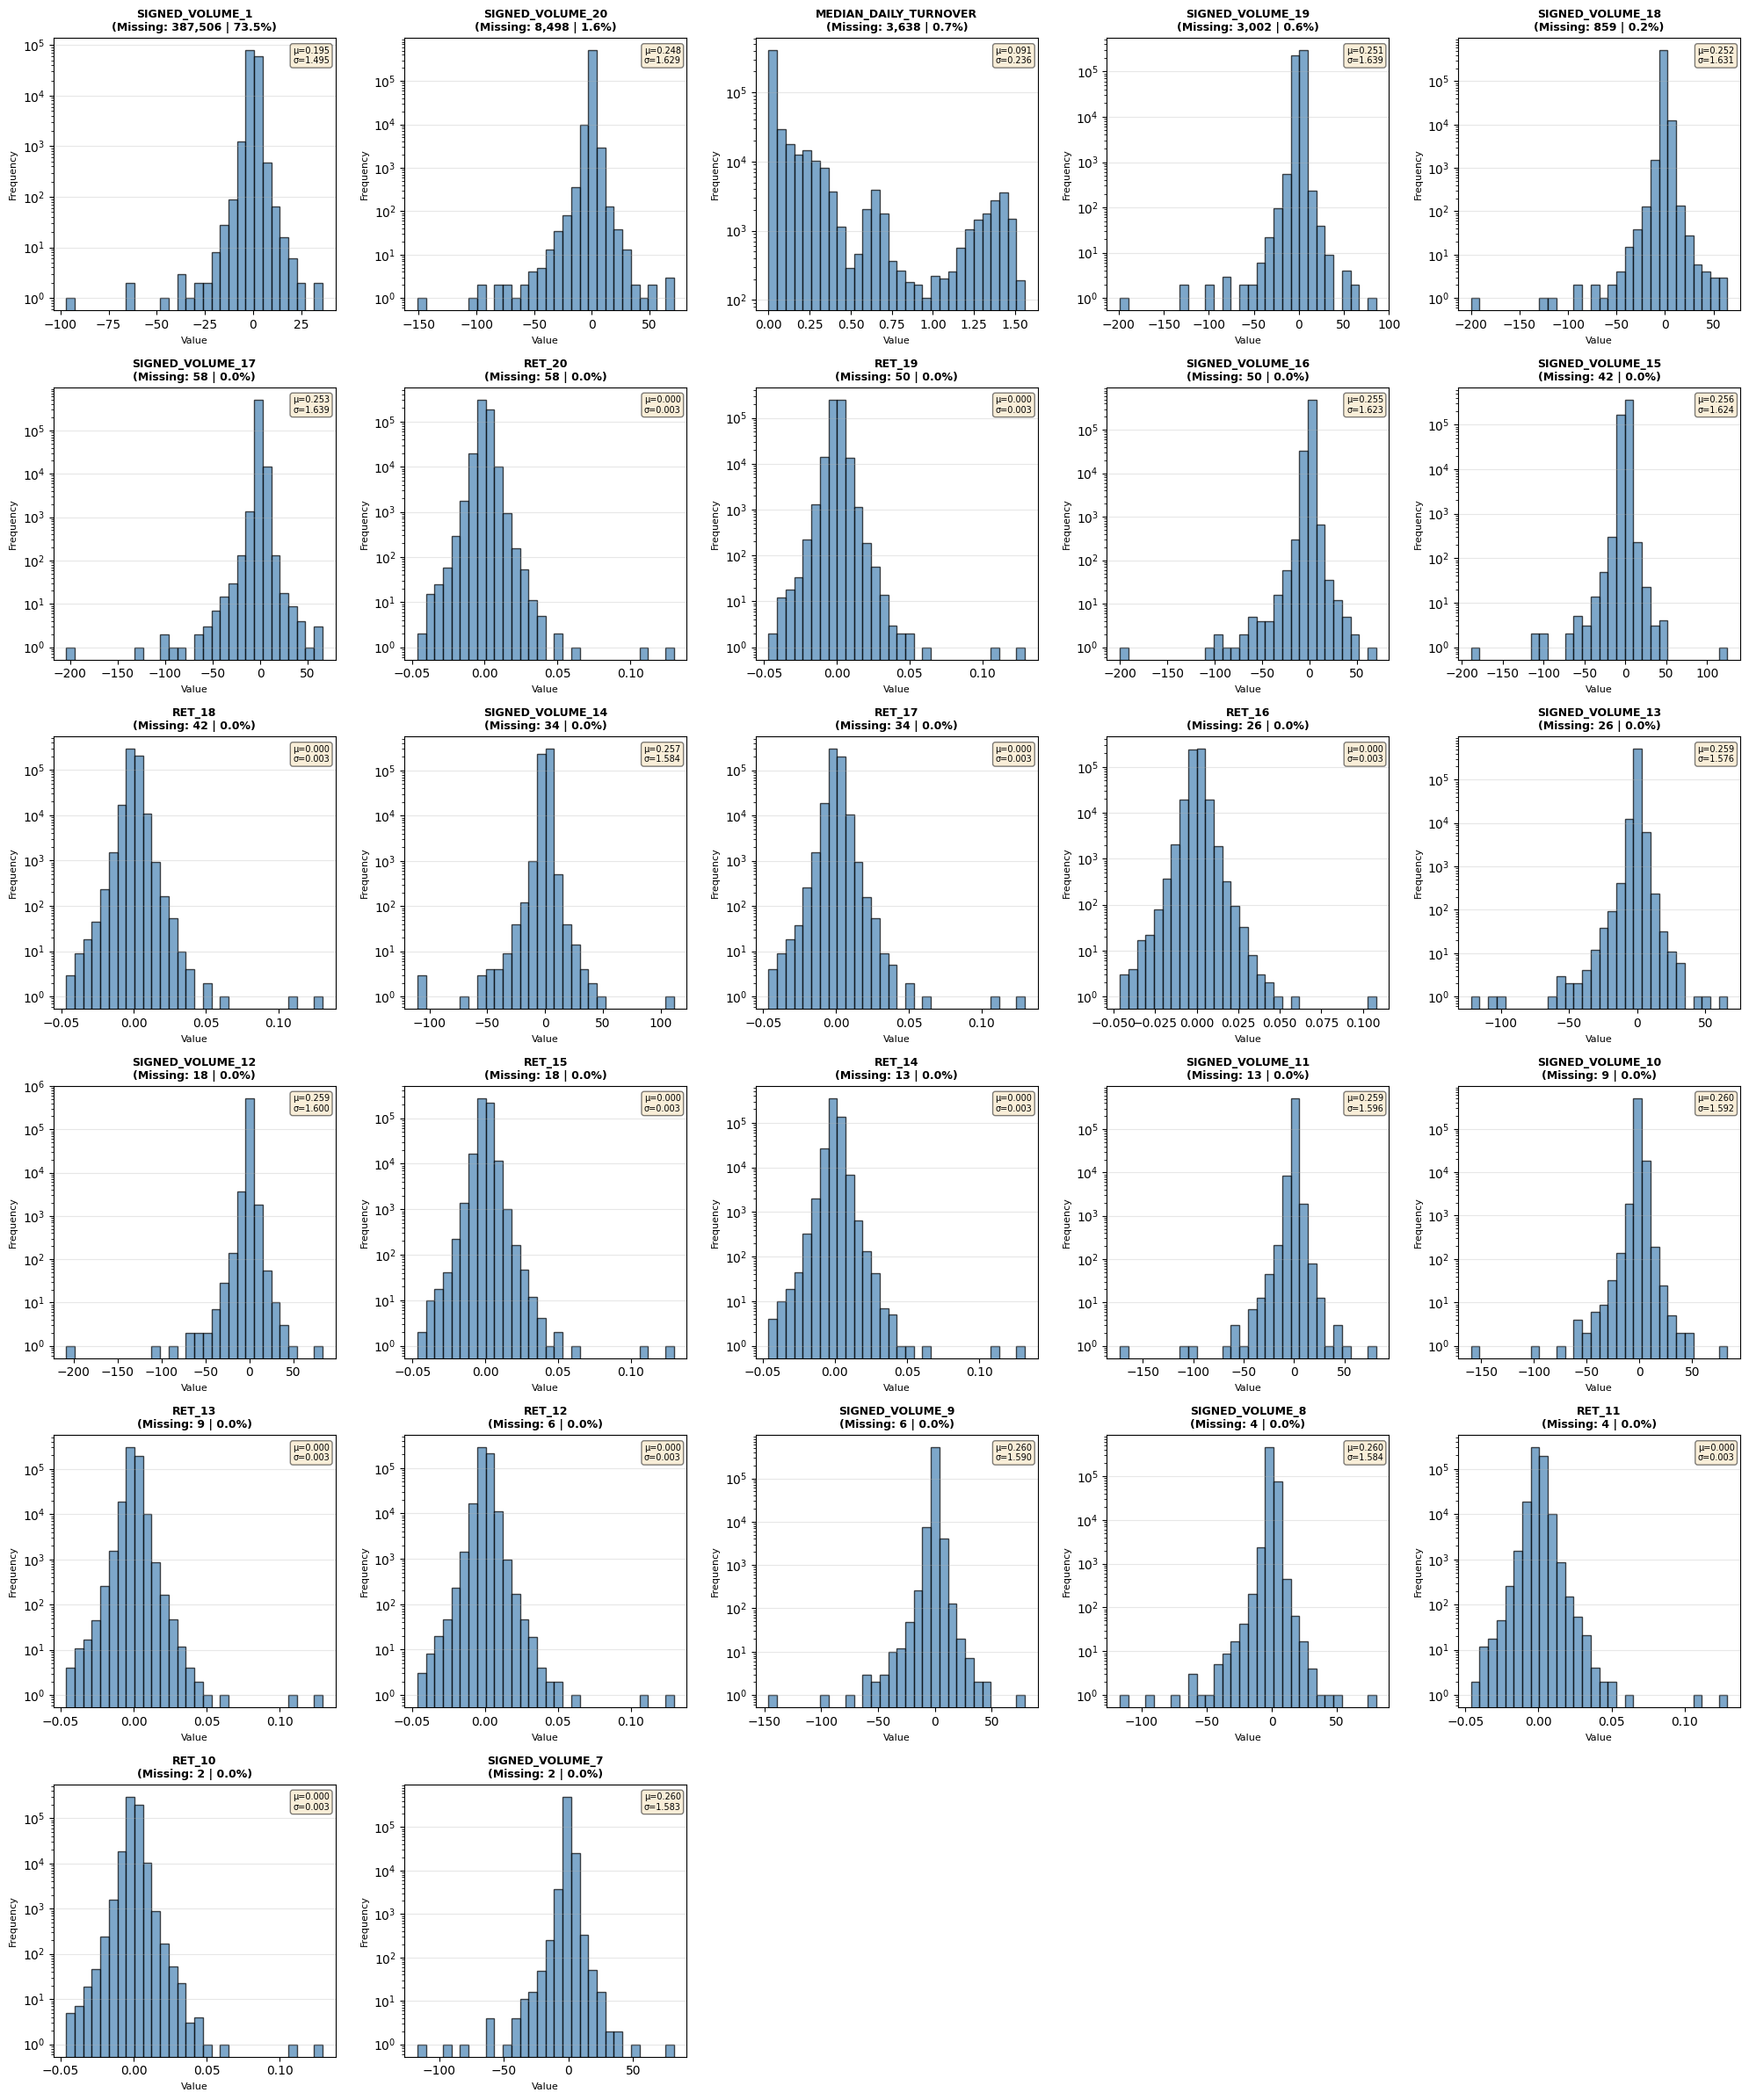


Total columns with missing data: 27


In [17]:
# Create histograms for columns with missing values to visualize data distribution
# Filter columns with missing values
missing_cols = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_cols) > 0:
    # Calculate number of rows needed (5 graphs per row)
    n_cols_to_plot = len(missing_cols)
    n_plots_per_row = 5
    n_rows = (n_cols_to_plot + n_plots_per_row - 1) // n_plots_per_row
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_plots_per_row, figsize=(20, 4 * n_rows))
    
    # Flatten axes array if needed
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    else:
        axes = axes.flatten()
    
    # Create a histogram for each column with missing values
    for idx, col in enumerate(missing_cols.index):
        ax = axes[idx]
        
        # Get data for this column (excluding NaN)
        data_col = data_train[col].dropna()
        
        # Create histogram
        ax.hist(data_col, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Calculate statistics
        count_missing = missing_cols[col]
        count_present = len(data_col)
        pct_missing = (count_missing / len(data_train)) * 100
        
        # Add title with statistics
        ax.set_title(f'{col}\n(Missing: {count_missing:,} | {pct_missing:.1f}%)', 
                    fontsize=9, fontweight='bold')
        ax.set_xlabel('Value', fontsize=8)
        ax.set_ylabel('Frequency', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        
        # Use logarithmic scale for better readability
        ax.set_yscale('log')
        
        # Add statistics text
        stats_text = f'μ={data_col.mean():.3f}\nσ={data_col.std():.3f}'
        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
               fontsize=7, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Hide unused subplots
    for idx in range(n_cols_to_plot, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal columns with missing data: {n_cols_to_plot}")
else:
    print("No missing values found in the dataset.")

# NaN Analysis on Engineered Features

In [18]:
# Check for NaN in engineered features
RET_features = [f"RET_{i}" for i in range(1, 21)]

# Create engineered features (same as in ridge_regression.py)
for i in [3, 5, 10, 15, 20]:
    data_train[f"AVERAGE_PERF_{i}"] = data_train[RET_features[:i]].mean(1)
    data_train[f"STD_PERF_{i}"] = data_train[RET_features[:i]].std(1)
    
    # Market-wide average performance and volatility on same day
    data_train[f"ALLOCATIONS_AVERAGE_PERF_{i}"] = data_train.groupby("TS")[
        f"AVERAGE_PERF_{i}"
    ].transform("mean")
    data_train[f"ALLOCATIONS_STD_PERF_{i}"] = data_train.groupby("TS")[
        f"STD_PERF_{i}"
    ].transform("mean")

# Check NaN in engineered features
engineered_features = (
    [f"AVERAGE_PERF_{i}" for i in [3, 5, 10, 15, 20]]
    + [f"ALLOCATIONS_AVERAGE_PERF_{i}" for i in [3, 5, 10, 15, 20]]
    + [f"STD_PERF_{i}" for i in [20]]
    + [f"ALLOCATIONS_STD_PERF_{i}" for i in [20]]
)
nan_in_engineered = data_train[engineered_features].isnull().sum()

print("NaN count in engineered features:")
print(nan_in_engineered[nan_in_engineered > 0])
print(f"\nTotal NaN in engineered features: {nan_in_engineered.sum()}")

# Check which rows have NaN in original features
rows_with_nan = data_train[RET_features].isnull().any(axis=1).sum()
print(f"\nRows with at least one NaN in RET features: {rows_with_nan}")
print(f"Percentage: {(rows_with_nan / len(data_train)) * 100:.2f}%")

C:\Users\vicca\AppData\Local\Temp\ipykernel_13332\1559570916.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  data_train[f"AVERAGE_PERF_{i}"] = data_train[RET_features[:i]].mean(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_13332\1559570916.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  data_train[f"STD_PERF_{i}"] = data_train[RET_features[:i]].std(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_13332\1559570916.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  data_train[f"AVERAGE_PERF_{i}"] = data_train[RET_features[:i]].mean(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_13332\1559570916.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  data_train[f"STD_PERF_{i}"] = data_train[RET_features[:i]].std(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_13332\1559570916.py:6: Pandas4Warnin

NaN count in engineered features:
Series([], dtype: int64)

Total NaN in engineered features: 0

Rows with at least one NaN in RET features: 58
Percentage: 0.01%


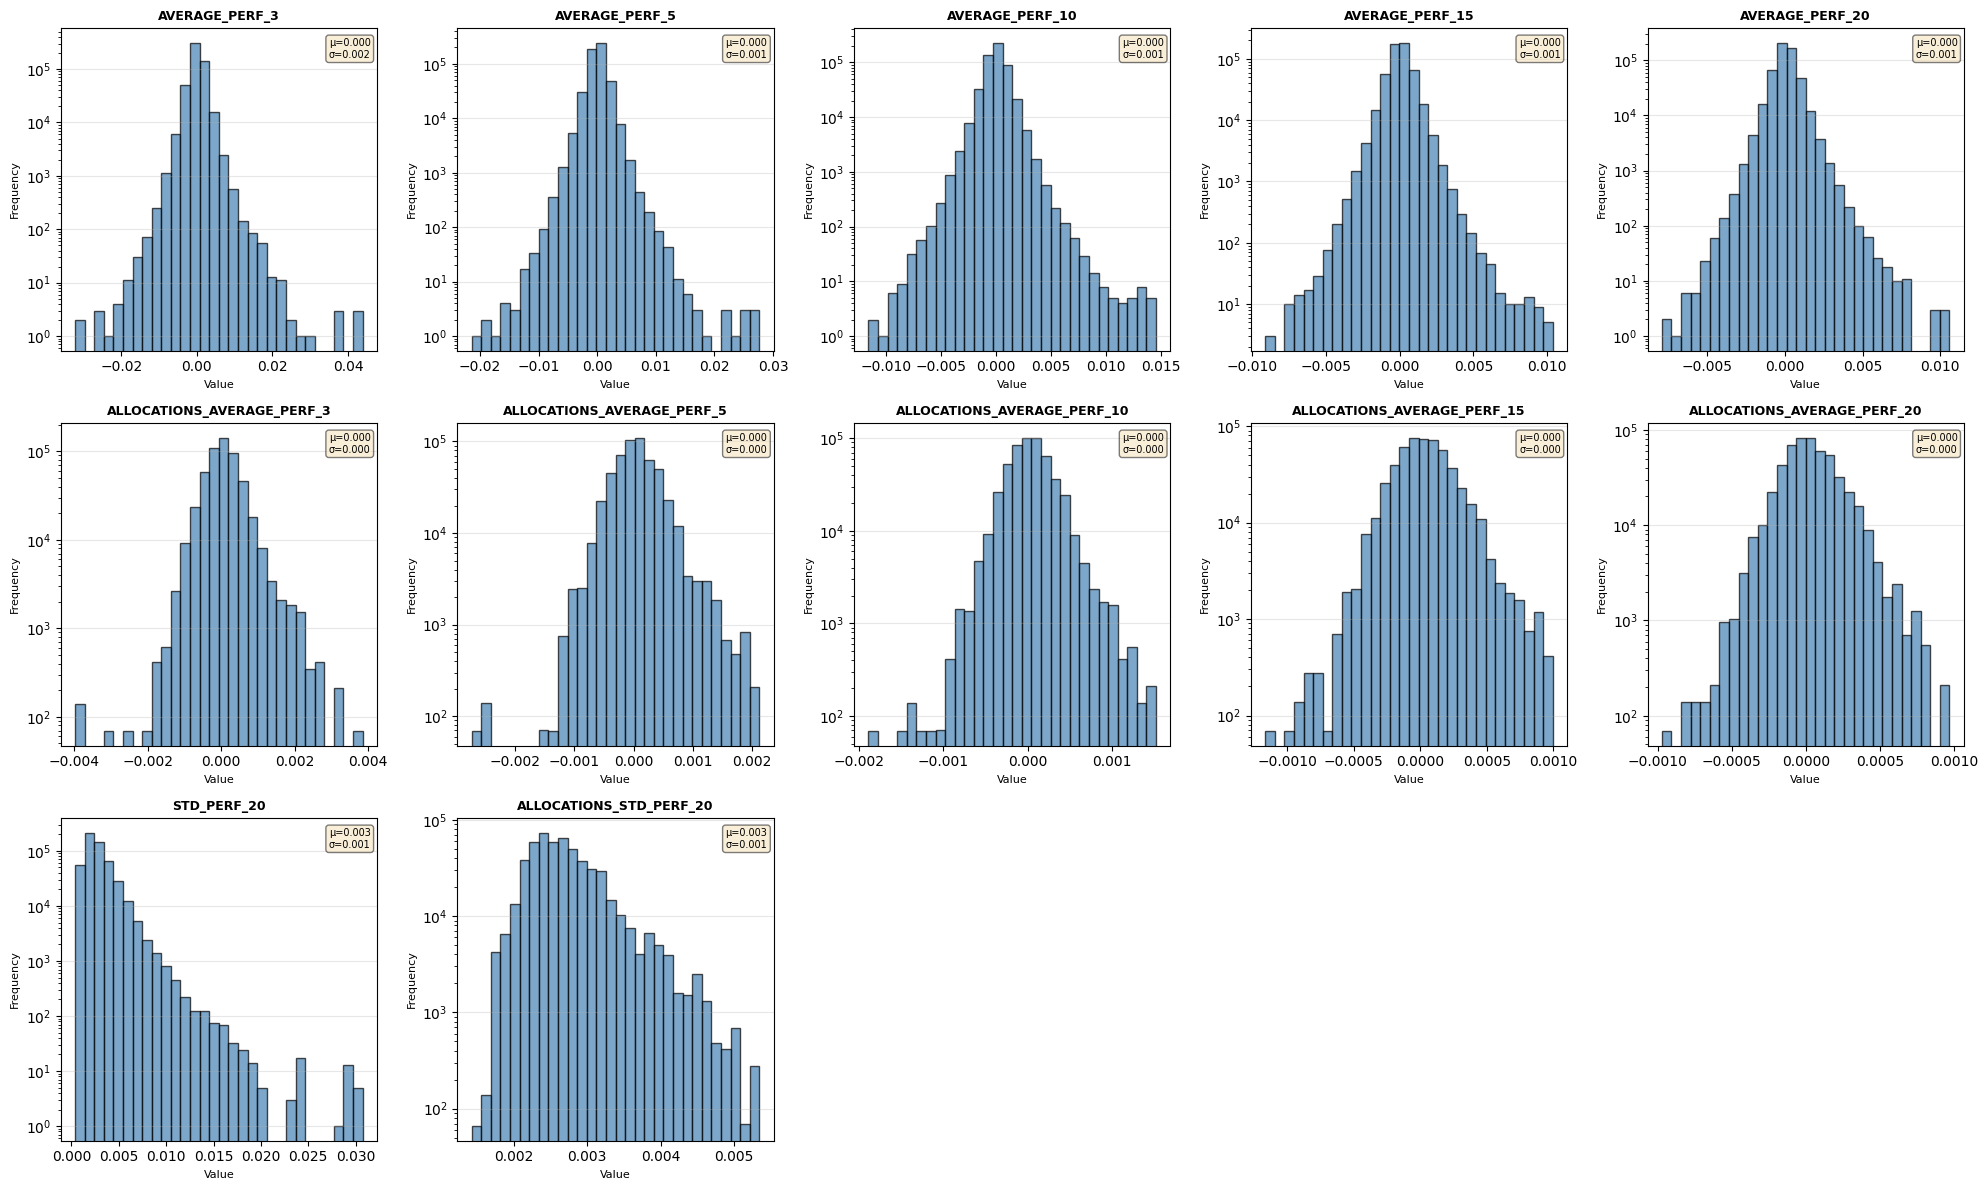

Engineered features visualization: 12 features displayed


In [19]:
# Visualize distributions of engineered features
# Calculate number of rows needed (5 graphs per row)
n_cols_to_plot = len(engineered_features)
n_plots_per_row = 5
n_rows = (n_cols_to_plot + n_plots_per_row - 1) // n_plots_per_row

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_plots_per_row, figsize=(20, 4 * n_rows))

# Flatten axes array if needed
if n_rows == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.flatten()

# Create a histogram for each engineered feature
for idx, col in enumerate(engineered_features):
    ax = axes[idx]
    
    # Get data for this column (excluding NaN - should be none as confirmed)
    data_col = data_train[col].dropna()
    
    # Create histogram
    ax.hist(data_col, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    
    # Add title
    ax.set_title(f'{col}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    # Use logarithmic scale for better readability
    ax.set_yscale('log')
    
    # Add statistics text
    stats_text = f'μ={data_col.mean():.3f}\nσ={data_col.std():.3f}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
           fontsize=7, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide unused subplots
for idx in range(n_cols_to_plot, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Engineered features visualization: {n_cols_to_plot} features displayed")

coherent to use the median for almost all the data, except the standards deviations, we can use the peak of the curve for them, using the principal mode of the distribution (Kernel density estimation)

Maybe as an alternative to this, we can use for all data MICE (Multiple Imputation by chained equations)